# Jupyter security advisories

Advisories across the Jupyter orgs, from
[`github-security-overview`](https://github.com/Yann-P/github-security-overview).

In [1]:
import os, trio, pandas as pd, matplotlib.pyplot as plt
from security_overview.fetch import STATES, fetch_advisories, github_client

ORGS = """binder-examples binderhub-ci-repos ipython jupyter jupyter-book
jupyter-governance jupyter-incubator jupyter-resources jupyter-server jupyter-standard
jupyter-standards jupyter-widgets jupyter-xeus jupytercon jupyterhealth jupyterhub
jupyterlab jupyterlite voila-dashboards voila-gallery""".split()

async def fetch():
    async with github_client(os.environ["GITHUB_TOKEN"]) as client:
        return await fetch_advisories(client, ORGS, STATES)

print("Fetching from GitHub, this takes about 20 seconds...")
advisories = trio.run(fetch)

df = pd.DataFrame({
    "state": [a["state"] for a in advisories],
    "opened": pd.to_datetime([a["created_at"] for a in advisories]).tz_localize(None),
    # a report leaves the pipeline when it is closed or published
    "resolved": pd.to_datetime([a["closed_at"] or a["published_at"] for a in advisories]).tz_localize(None),
})
print(len(df), "advisories")
df.head()

Fetching from GitHub, this takes about 20 seconds...
272 advisories


,state,opened,resolved
0,triage,2026-08-27 12:10:29,NaT
1,closed,2025-04-07 00:16:13,2025-04-07 21:10:00
2,closed,2025-01-09 04:04:54,2026-03-24 21:05:44
3,closed,2023-01-03 16:19:02,2024-08-08 12:02:00
4,published,2023-02-06 12:58:58,2023-02-10 09:23:53


Everything below is built from one table: how many reports arrived each month, split by the state
they are in today. Months where nothing was reported are kept as zeroes so they stay on the axis.

States are ordered oldest-outcome first, which is also the order they stack in the charts.

In [10]:
ORDER = ["closed", "published", "draft", "triage"]
COLORS = {"closed": "#b0b0b0", "published": "#55a868", "draft": "#4c72b0", "triage": "#dd8452"}

by_month = df.groupby([df["opened"].dt.to_period("M"), "state"]).size().unstack(fill_value=0)
months = pd.period_range(by_month.index.min(), pd.Timestamp.now().to_period("M"), freq="M")
by_month = by_month.reindex(index=months, columns=ORDER, fill_value=0)

totals = by_month.sum()
by_month.tail()

state,closed,published,draft,triage
2026-04,14,6,4,0
2026-05,10,5,4,0
2026-06,10,4,10,0
2026-07,9,3,6,4
2026-08,7,0,5,7


## New GHSA (GitHub Security Advisories) opened per month

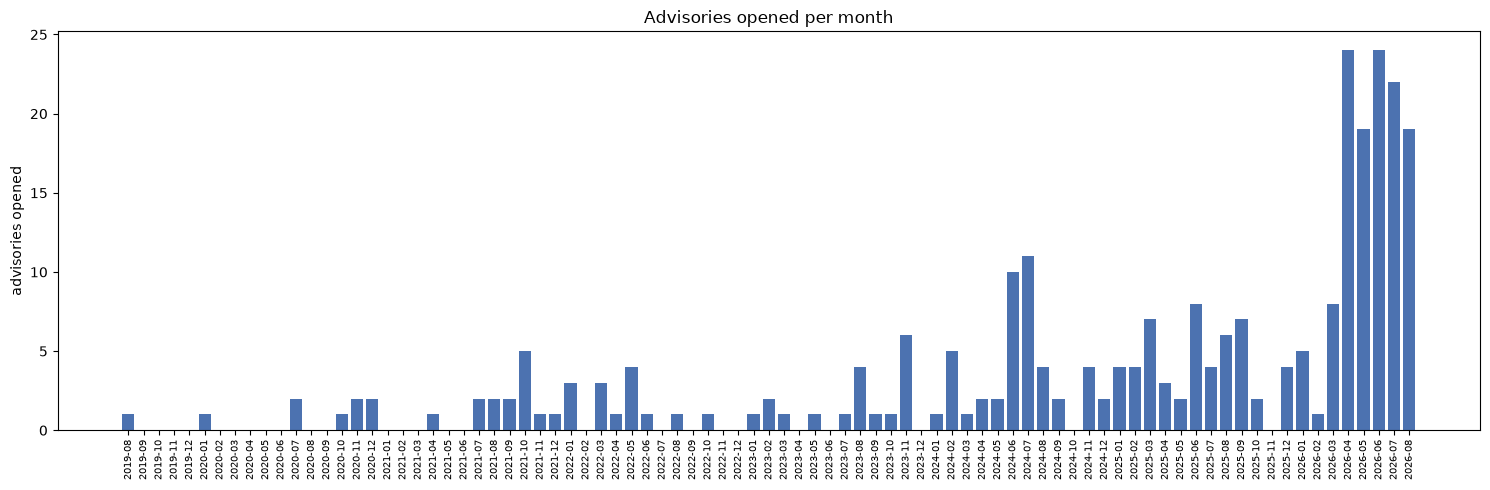

In [17]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(by_month.index.astype(str), by_month.sum(axis=1), color=COLORS["draft"])

ax.set_title("Advisories opened per month")
ax.set_ylabel("advisories opened")
ax.tick_params(axis="x", rotation=90, labelsize=7)
fig.tight_layout()

## Advisories by state

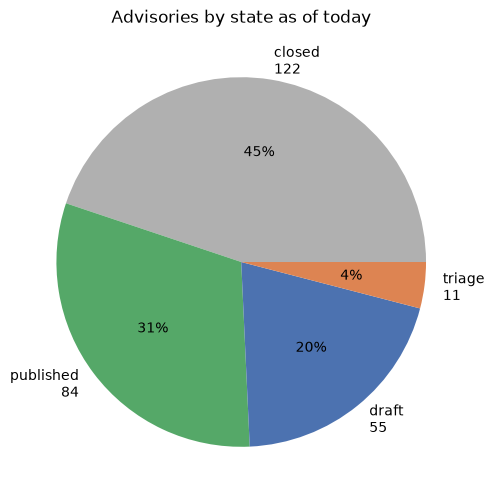

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Advisories by state as of today")
ax.pie(totals,
       labels=[f"{state}\n{count}" for state, count in totals.items()],
       colors=[COLORS[state] for state in totals.index],
       autopct="%1.0f%%")

## Backlog vs. everything ever published

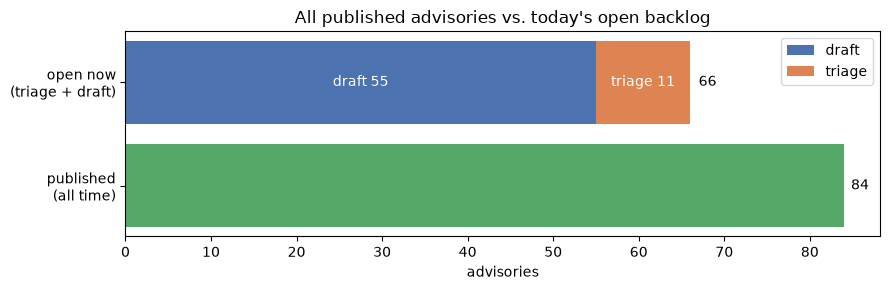

In [13]:
fig, ax = plt.subplots(figsize=(9, 3))

bars = ax.barh("published\n(all time)", totals["published"], color=COLORS["published"])
ax.bar_label(bars, padding=5)

left = 0
for state in ["draft", "triage"]:
    bars = ax.barh("open now\n(triage + draft)", totals[state], left=left, color=COLORS[state], label=state)
    ax.bar_label(bars, labels=[f"{state} {totals[state]}"], label_type="center", color="white")
    left += totals[state]
ax.text(left + 1, 1, str(left), va="center")

ax.set_xlabel("advisories")
ax.set_title("All published advisories vs. today's open backlog")
ax.legend()
fig.tight_layout()

## What happened to each month's reports

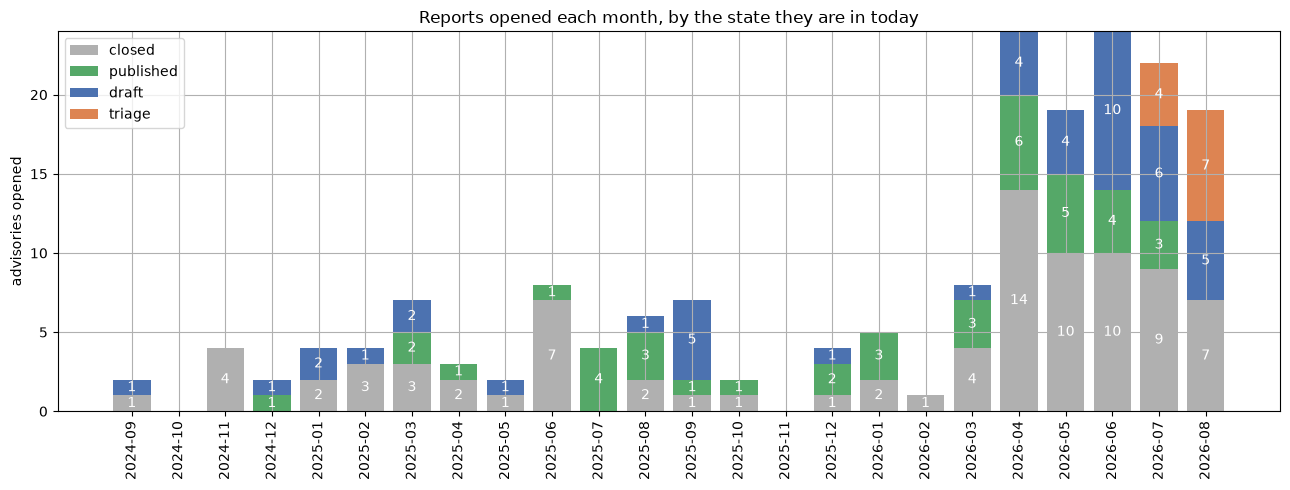

In [14]:
recent = by_month.tail(24)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = 0
for state in ORDER:
    bars = ax.bar(recent.index.astype(str), recent[state], bottom=bottom, color=COLORS[state], label=state)
    bottom = bottom + recent[state]
    ax.bar_label(bars, label_type="center", color="white", fmt=lambda x: x if x > 0 else '')


ax.set_title("Reports opened each month, by the state they are in today")
ax.set_ylabel("advisories opened")
ax.tick_params(axis="x", rotation=90)
ax.grid()
ax.legend()
fig.tight_layout()

## Reports arriving vs. reports resolved

Shading shows whether we gained or lost ground that month.

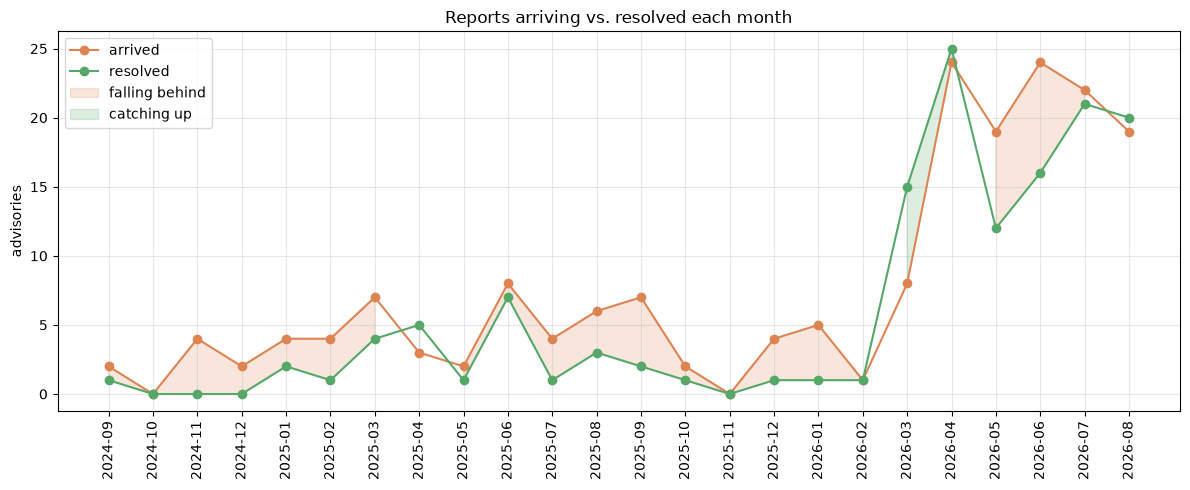

In [15]:
arrived = by_month.sum(axis=1).tail(24)
resolved = df["resolved"].dropna().dt.to_period("M").value_counts().reindex(months, fill_value=0).tail(24)

x = range(len(arrived))
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, arrived, marker="o", color=COLORS["triage"], label="arrived")
ax.plot(x, resolved, marker="o", color=COLORS["published"], label="resolved")
ax.fill_between(x, arrived, resolved, where=arrived >= resolved, color=COLORS["triage"], alpha=0.2, label="falling behind")
ax.fill_between(x, arrived, resolved, where=arrived < resolved, color=COLORS["published"], alpha=0.2, label="catching up")

ax.set_xticks(list(x), arrived.index.astype(str), rotation=90)
ax.set_title("Reports arriving vs. resolved each month")
ax.set_ylabel("advisories")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Median age of the backlog, month by month

We know when every report arrived and when it left, so for any past date we can rebuild which reports
were open then and how old each one was. 

GitHub never records the triage-to-draft transition or any stateX-to-stateY transition unfortunately.

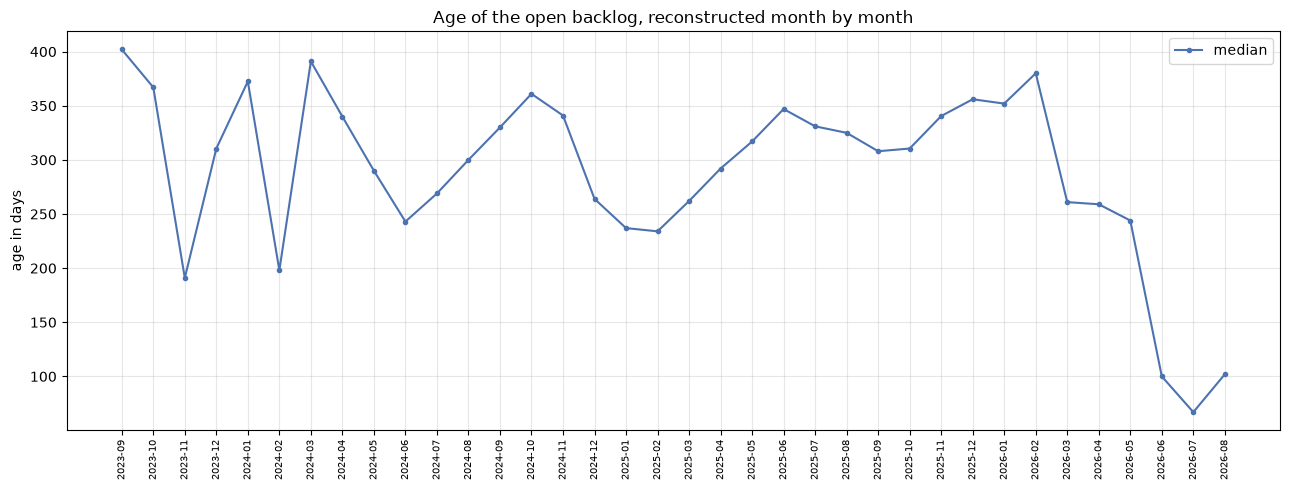

In [19]:
def backlog_on(day):
    """The reports that were still open on `day`."""
    return df[(df["opened"] <= day) & (df["resolved"].isna() | (df["resolved"] > day))]

recent_months = months[-12*3:]
history = pd.DataFrame([
    (month.end_time - backlog_on(month.end_time)["opened"]).dt.days.quantile([0.5]).values
    for month in recent_months
], index=recent_months.astype(str), columns=["median"])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(history.index, history["median"], color=COLORS["draft"], marker="o", ms=3, label="median")

ax.set_title("Age of the open backlog, reconstructed month by month")
ax.set_ylabel("age in days")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()